In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path to the surface temperature band (relative to the notebooks folder)
st_path = "../data/raw/LC09_L2SP_092086_20240203_20240208_02_T1_ST_B10.TIF"

# Open the file and inspect its metadata — don't read the pixels yet
with rasterio.open(st_path) as src:
    print("Dimensions (height x width):", src.height, "x", src.width)
    print("Number of bands:", src.count)
    print("Data type:", src.dtypes[0])
    print("Coordinate system (CRS):", src.crs)
    print("Nodata value:", src.nodata)

Dimensions (height x width): 7771 x 7741
Number of bands: 1
Data type: uint16
Coordinate system (CRS): EPSG:32655
Nodata value: 0.0


Array shape: (7771, 7741)
Min value: 0  Max value: 52967


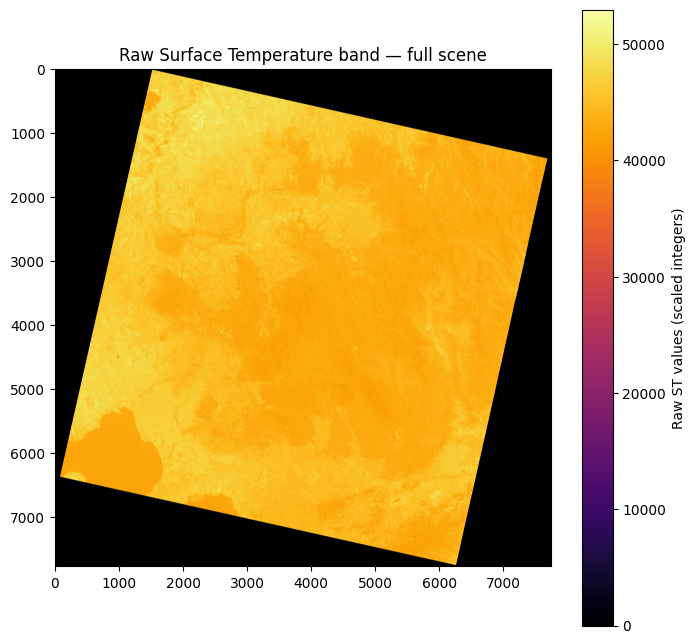

In [2]:
# Read the single band into a numpy array
with rasterio.open(st_path) as src:
    st_raw = src.read(1)  # read band 1 into a 2D array

print("Array shape:", st_raw.shape)
print("Min value:", st_raw.min(), " Max value:", st_raw.max())

# Quick look at the raw scene (still in scaled integers, not °C yet)
plt.figure(figsize=(8, 8))
plt.imshow(st_raw, cmap="inferno")
plt.colorbar(label="Raw ST values (scaled integers)")
plt.title("Raw Surface Temperature band — full scene")
plt.show()

In [3]:
# Landsat Collection 2 Level-2 surface temperature scaling:
#   Kelvin = raw * 0.00341802 + 149.0
#   Celsius = Kelvin - 273.15
# Convert to float first so we can hold decimals and NaN
st = st_raw.astype("float32")

# Mask the nodata pixels (raw value 0) so they don't corrupt the stats.
# np.nan = "not a number", the standard marker for empty cells.
st[st == 0] = np.nan

# Apply the scale + offset to get Kelvin, then subtract to get Celsius
st_celsius = st * 0.00341802 + 149.0 - 273.15

# Report the real temperature range, ignoring the NaN pixels
print("Min temp (°C):", np.nanmin(st_celsius))
print("Max temp (°C):", np.nanmax(st_celsius))
print("Mean temp (°C):", np.nanmean(st_celsius))

Min temp (°C): 15.195831
Max temp (°C): 56.892273
Mean temp (°C): 27.737349


In [4]:
import geopandas as gpd

# Load the all-of-Australia LGA boundaries
lga_path = "../data/raw/boundaries/ABS_ASGS_Edition_3_-_2021_Local_Government_Areas.shp"
lgas = gpd.read_file(lga_path)

print("Number of LGAs (all Australia):", len(lgas))
print("CRS:", lgas.crs)
print("\nColumn names:")
print(lgas.columns.tolist())
print("\nFirst few rows:")
lgas.head()

Number of LGAs (all Australia): 566
CRS: EPSG:3857

Column names:
['objectid', 'shape', 'lga_code_2', 'lga_name_2', 'state_code', 'state_name', 'aus_code_2', 'aus_name_2', 'area_alber', 'asgs_loci_', 'st_lengths', 'st_areasha', 'geometry']

First few rows:


,objectid,shape,lga_code_2,lga_name_2,state_code,state_name,aus_code_2,aus_name_2,area_alber,asgs_loci_,st_lengths,st_areasha,geometry
0,1,None,10050,Albury,1,New South Wales,AUS,Australia,305.6386,http://linked.data.gov.au/dataset/asgsed3/LGA2...,1.634195e+05,4.682638e+08,"POLYGON ((16349009.881 -4310661.077, 16348949...."
1,2,None,10180,Armidale Regional,1,New South Wales,AUS,Australia,7809.4406,http://linked.data.gov.au/dataset/asgsed3/LGA2...,7.213707e+05,1.052539e+10,"POLYGON ((16845337.899 -3538204.006, 16845331...."
2,3,None,10250,Ballina,1,New South Wales,AUS,Australia,484.9692,http://linked.data.gov.au/dataset/asgsed3/LGA2...,1.794449e+05,6.344631e+08,"MULTIPOLYGON (((17075261.403 -3351785.021, 170..."
3,4,None,10300,Balranald,1,New South Wales,AUS,Australia,21690.7493,http://linked.data.gov.au/dataset/asgsed3/LGA2...,1.409103e+06,3.160499e+10,"POLYGON ((15919168.62 -3999520.494, 15920398.8..."
4,5,None,10470,Bathurst Regional,1,New South Wales,AUS,Australia,3817.8645,http://linked.data.gov.au/dataset/asgsed3/LGA2...,6.599880e+05,5.496302e+09,"POLYGON ((16688141.062 -3947961.554, 16688067...."


In [5]:
# First filter to Victoria
vic = lgas[lgas["state_name"] == "Victoria"].copy()
print("LGAs in Victoria:", len(vic))

# List them alphabetically so we can pick the Melbourne metro ones
for name in sorted(vic["lga_name_2"].tolist()):
    print(name)

LGAs in Victoria: 82
Alpine
Ararat
Ballarat
Banyule
Bass Coast
Baw Baw
Bayside (Vic.)
Benalla
Boroondara
Brimbank
Buloke
Campaspe
Cardinia
Casey
Central Goldfields
Colac Otway
Corangamite
Darebin
East Gippsland
Frankston
Gannawarra
Glen Eira
Glenelg
Golden Plains
Greater Bendigo
Greater Dandenong
Greater Geelong
Greater Shepparton
Hepburn
Hindmarsh
Hobsons Bay
Horsham
Hume
Indigo
Kingston (Vic.)
Knox
Latrobe (Vic.)
Loddon
Macedon Ranges
Manningham
Mansfield
Maribyrnong
Maroondah
Melbourne
Melton
Migratory - Offshore - Shipping (Vic.)
Mildura
Mitchell
Moira
Monash
Moonee Valley
Moorabool
Moreland
Mornington Peninsula
Mount Alexander
Moyne
Murrindindi
Nillumbik
No usual address (Vic.)
Northern Grampians
Port Phillip
Pyrenees
Queenscliffe
South Gippsland
Southern Grampians
Stonnington
Strathbogie
Surf Coast
Swan Hill
Towong
Unincorporated Vic
Wangaratta
Warrnambool
Wellington
West Wimmera
Whitehorse
Whittlesea
Wodonga
Wyndham
Yarra
Yarra Ranges
Yarriambiack


LGAs selected: 13 (expected 13)

Selected:
['Banyule', 'Bayside (Vic.)', 'Boroondara', 'Darebin', 'Glen Eira', 'Hobsons Bay', 'Maribyrnong', 'Melbourne', 'Moonee Valley', 'Moreland', 'Port Phillip', 'Stonnington', 'Yarra']


<Axes: >

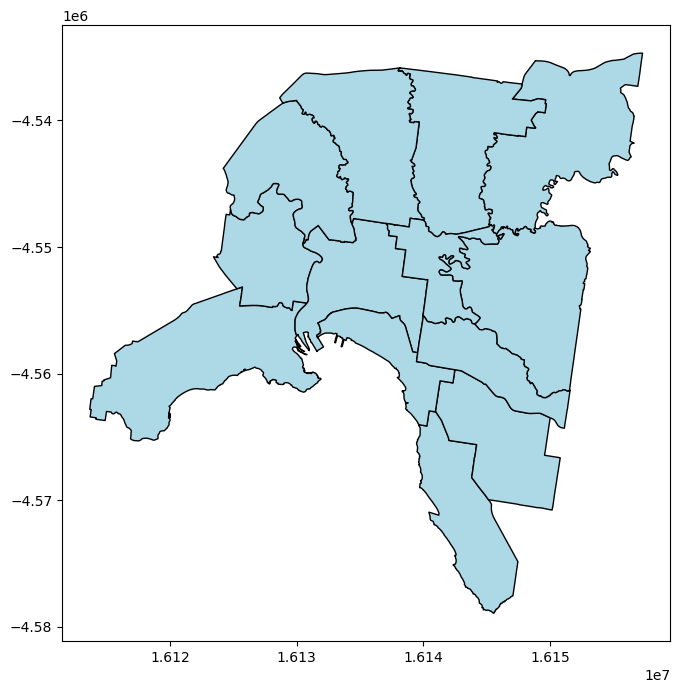

In [6]:
# Inner + middle Melbourne councils (contiguous study area)
melb_lgas = [
    "Melbourne", "Port Phillip", "Yarra", "Stonnington",
    "Maribyrnong", "Moonee Valley", "Moreland", "Darebin",
    "Glen Eira", "Bayside (Vic.)", "Boroondara", "Banyule", "Hobsons Bay"
]

melb = vic[vic["lga_name_2"].isin(melb_lgas)].copy()

print("LGAs selected:", len(melb), "(expected 13)")
print("\nSelected:")
print(sorted(melb["lga_name_2"].tolist()))

# Quick plot to eyeball that they form one contiguous blob
melb.plot(figsize=(8, 8), edgecolor="black", facecolor="lightblue")

In [7]:
# Reproject the Melbourne LGAs from Web Mercator (3857) to the raster's CRS (UTM 55S, 32655)
melb_utm = melb.to_crs("EPSG:32655")

print("Boundaries CRS now:", melb_utm.crs)

# Merge all 13 LGAs into one combined shape for clipping
# (we keep melb_utm separate too, for per-LGA stats later)
melb_dissolved = melb_utm.dissolve()
print("Dissolved into", len(melb_dissolved), "shape for clipping")

Boundaries CRS now: EPSG:32655
Dissolved into 1 shape for clipping


In [8]:
from rasterio.mask import mask

# Re-open the temperature raster and clip it to the dissolved Melbourne shape
with rasterio.open(st_path) as src:
    # mask() crops the raster to the geometry and returns the clipped array + its transform
    clipped_raw, clipped_transform = mask(
        src,
        melb_dissolved.geometry,   # the single dissolved Melbourne shape
        crop=True,                 # crop the output to the shape's bounding box
        nodata=0                   # keep 0 as the nodata marker
    )

# mask() returns a 3D array (bands, height, width); grab the single band
clipped_raw = clipped_raw[0]

print("Clipped array shape:", clipped_raw.shape)
print("Original was: (7771, 7741)")

# Convert the clipped data to Celsius (same scaling as before)
clipped = clipped_raw.astype("float32")
clipped[clipped == 0] = np.nan
clipped_celsius = clipped * 0.00341802 + 149.0 - 273.15

print("\nMelbourne temperature range:")
print("Min (°C):", np.nanmin(clipped_celsius))
print("Max (°C):", np.nanmax(clipped_celsius))
print("Mean (°C):", np.nanmean(clipped_celsius))

Clipped array shape: (1168, 1136)
Original was: (7771, 7741)

Melbourne temperature range:
Min (°C): 21.857574
Max (°C): 50.206635
Mean (°C): 35.77704


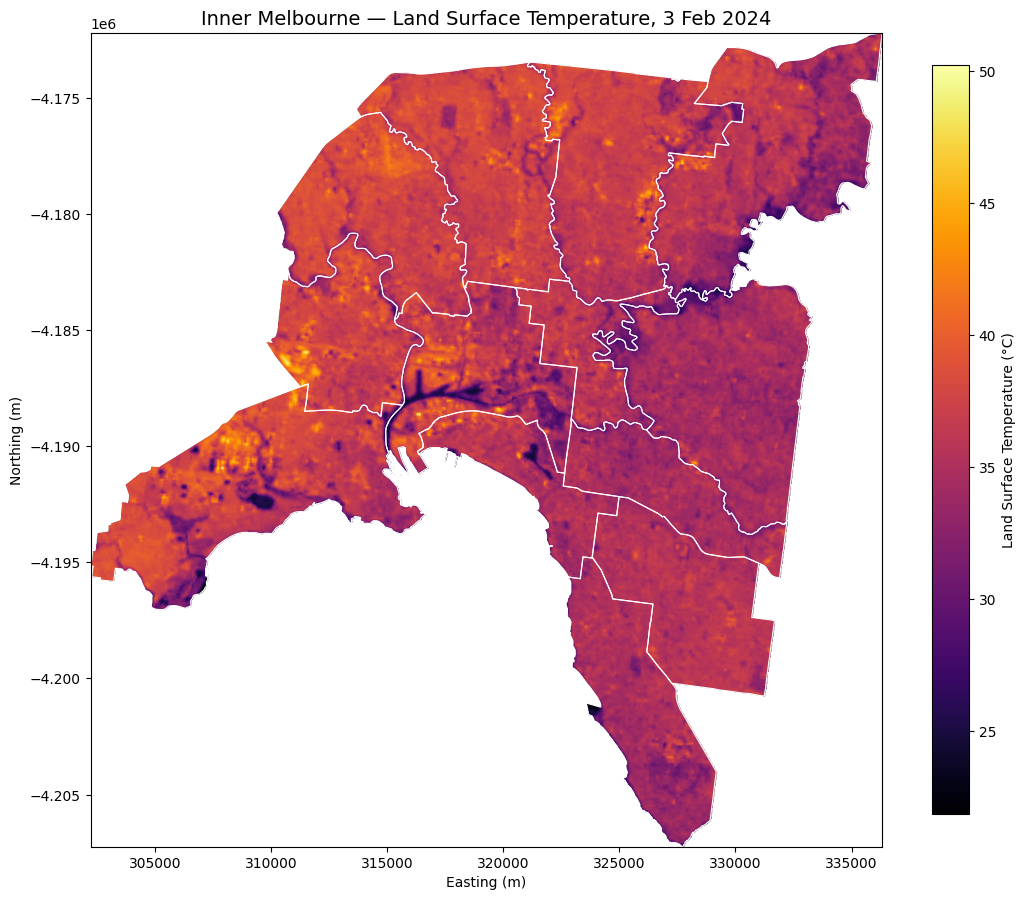

In [9]:
fig, ax = plt.subplots(figsize=(11, 11))

# Use the clipped transform so the map is correctly georeferenced
from rasterio.plot import show
img = ax.imshow(
    clipped_celsius,
    cmap="inferno",
    extent=[
        clipped_transform[2],
        clipped_transform[2] + clipped_transform[0] * clipped_celsius.shape[1],
        clipped_transform[5] + clipped_transform[4] * clipped_celsius.shape[0],
        clipped_transform[5]
    ]
)

# Overlay the LGA boundaries so the suburbs are visible on the heat map
melb_utm.boundary.plot(ax=ax, edgecolor="white", linewidth=0.8)

plt.colorbar(img, ax=ax, label="Land Surface Temperature (°C)", shrink=0.7)
ax.set_title("Inner Melbourne — Land Surface Temperature, 3 Feb 2024", fontsize=14)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

In [10]:
# Paths to the red (B4) and near-infrared (B5) surface reflectance bands
red_path = "../data/raw/LC09_L2SP_092086_20240203_20240208_02_T1_SR_B4.TIF"
nir_path = "../data/raw/LC09_L2SP_092086_20240203_20240208_02_T1_SR_B5.TIF"

# Clip both bands to the same Melbourne shape, exactly like we did for temperature
with rasterio.open(red_path) as src:
    red_clipped, _ = mask(src, melb_dissolved.geometry, crop=True, nodata=0)
red_clipped = red_clipped[0].astype("float32")

with rasterio.open(nir_path) as src:
    nir_clipped, _ = mask(src, melb_dissolved.geometry, crop=True, nodata=0)
nir_clipped = nir_clipped[0].astype("float32")

# Mask nodata (0) in both
red_clipped[red_clipped == 0] = np.nan
nir_clipped[nir_clipped == 0] = np.nan

# Apply Collection 2 surface reflectance scaling: reflectance = raw * 0.0000275 - 0.2
red = red_clipped * 0.0000275 - 0.2
nir = nir_clipped * 0.0000275 - 0.2

# NDVI = (NIR - Red) / (NIR + Red)
ndvi = (nir - red) / (nir + red)

print("NDVI shape:", ndvi.shape, "(should match temp:", clipped_celsius.shape, ")")
print("NDVI min:", np.nanmin(ndvi))
print("NDVI max:", np.nanmax(ndvi))
print("NDVI mean:", np.nanmean(ndvi))

NDVI shape: (1168, 1136) (should match temp: (1168, 1136) )
NDVI min: -587.03577
NDVI max: 569.7056
NDVI mean: 0.39935905


NDVI after cleaning:
Min: -0.9994198
Max: 0.98236173
Mean: 0.4075172


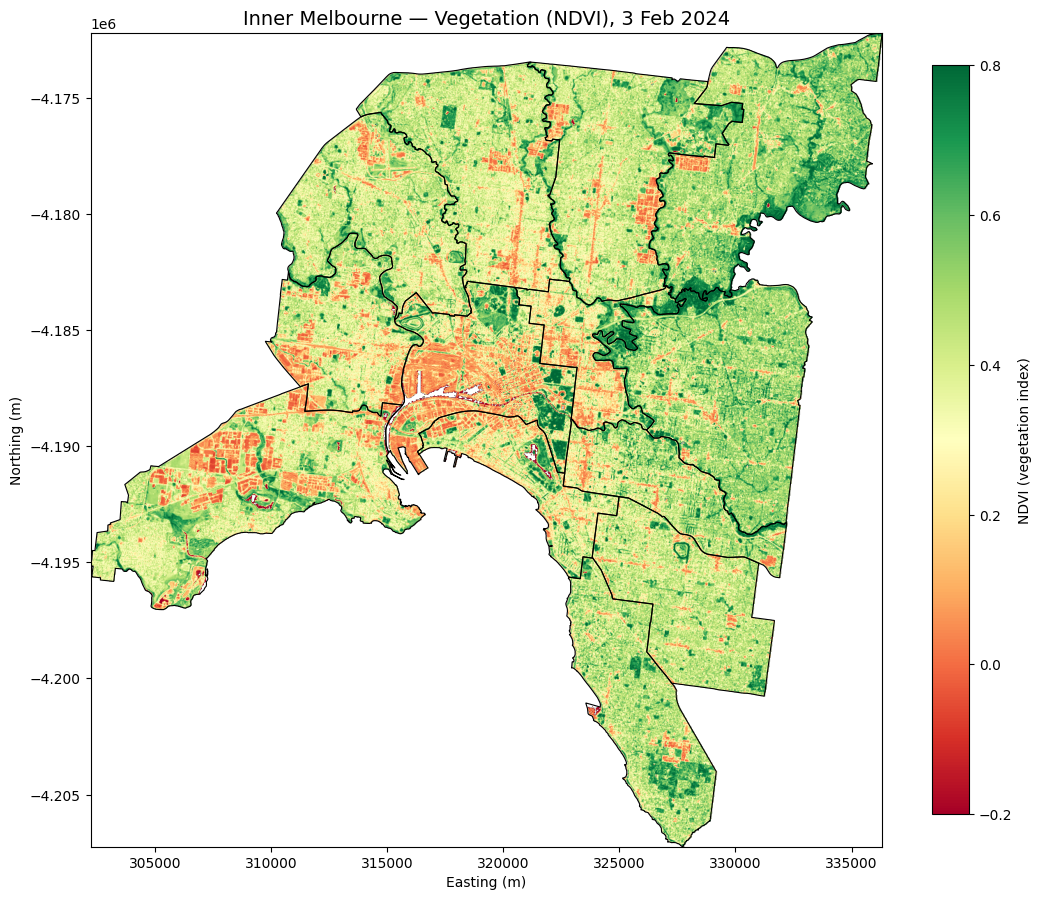

In [11]:
# Clip NDVI to its physically valid range [-1, 1].
# Pixels outside this are division-by-near-zero artifacts -> set to NaN.
ndvi = np.where((ndvi < -1) | (ndvi > 1), np.nan, ndvi)

print("NDVI after cleaning:")
print("Min:", np.nanmin(ndvi))
print("Max:", np.nanmax(ndvi))
print("Mean:", np.nanmean(ndvi))

# Visualize NDVI — green = vegetated, brown/white = bare/built
fig, ax = plt.subplots(figsize=(11, 11))
extent = [
    clipped_transform[2],
    clipped_transform[2] + clipped_transform[0] * ndvi.shape[1],
    clipped_transform[5] + clipped_transform[4] * ndvi.shape[0],
    clipped_transform[5]
]
img = ax.imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8, extent=extent)
melb_utm.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8)
plt.colorbar(img, ax=ax, label="NDVI (vegetation index)", shrink=0.7)
ax.set_title("Inner Melbourne — Vegetation (NDVI), 3 Feb 2024", fontsize=14)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

Valid pixels for correlation: 603568
Correlation (NDVI vs Temperature): -0.38


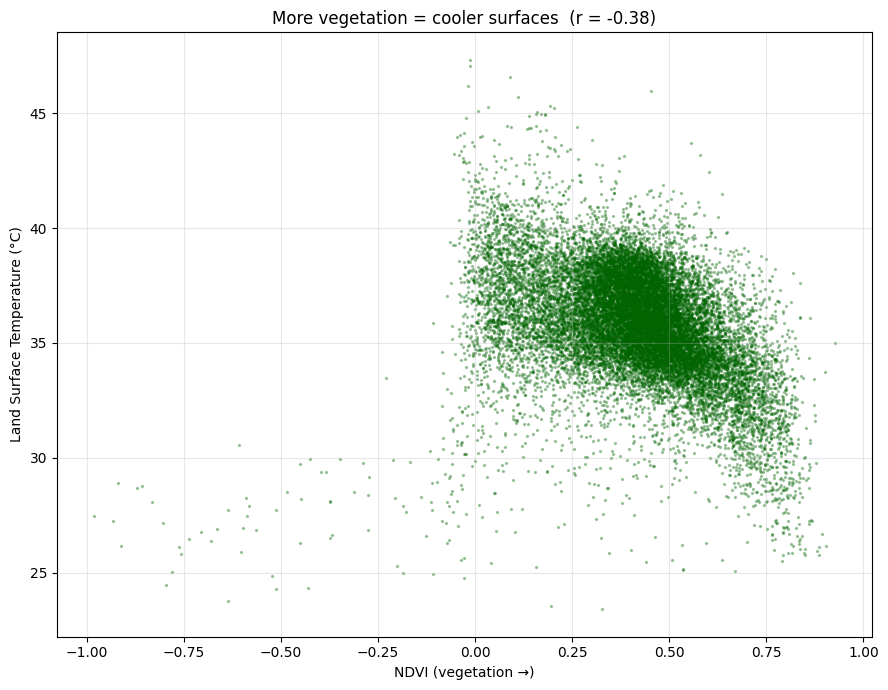

In [12]:
# Flatten both arrays to 1D and keep only pixels where BOTH have valid data
temp_flat = clipped_celsius.flatten()
ndvi_flat = ndvi.flatten()

valid = ~np.isnan(temp_flat) & ~np.isnan(ndvi_flat)
temp_valid = temp_flat[valid]
ndvi_valid = ndvi_flat[valid]

print("Valid pixels for correlation:", len(temp_valid))

# Pearson correlation between vegetation and temperature
r = np.corrcoef(ndvi_valid, temp_valid)[0, 1]
print("Correlation (NDVI vs Temperature):", round(r, 3))

# Scatter plot (sample 20k points so it's not a solid blob)
sample = np.random.choice(len(temp_valid), size=20000, replace=False)
plt.figure(figsize=(9, 7))
plt.scatter(ndvi_valid[sample], temp_valid[sample], s=2, alpha=0.3, c="darkgreen")
plt.xlabel("NDVI (vegetation →)")
plt.ylabel("Land Surface Temperature (°C)")
plt.title(f"More vegetation = cooler surfaces  (r = {round(r, 2)})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Pixels before water mask: 603568
Pixels after water mask:  594830
Removed (water/non-land): 8738

Correlation (land only): -0.465
Correlation (with water): -0.38   <- for comparison


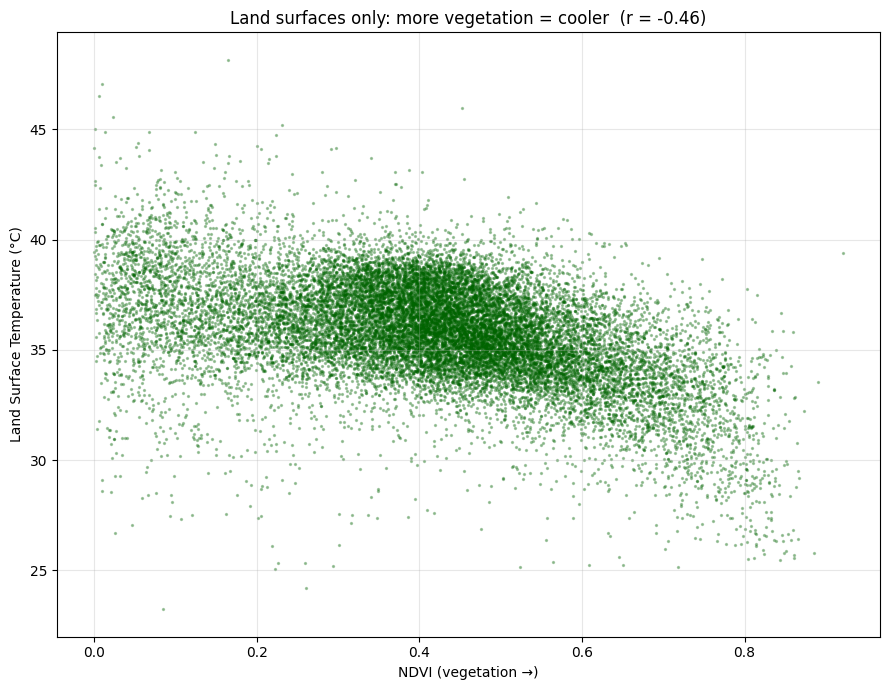

In [13]:
# Water has negative NDVI. Mask out NDVI < 0 to keep only land surfaces.
land = ndvi_valid >= 0

ndvi_land = ndvi_valid[land]
temp_land = temp_valid[land]

print("Pixels before water mask:", len(ndvi_valid))
print("Pixels after water mask: ", len(ndvi_land))
print("Removed (water/non-land):", len(ndvi_valid) - len(ndvi_land))

# Recompute correlation on land only
r_land = np.corrcoef(ndvi_land, temp_land)[0, 1]
print("\nCorrelation (land only):", round(r_land, 3))
print("Correlation (with water):", -0.38, "  <- for comparison")

# Updated scatter
sample = np.random.choice(len(temp_land), size=20000, replace=False)
plt.figure(figsize=(9, 7))
plt.scatter(ndvi_land[sample], temp_land[sample], s=2, alpha=0.3, c="darkgreen")
plt.xlabel("NDVI (vegetation →)")
plt.ylabel("Land Surface Temperature (°C)")
plt.title(f"Land surfaces only: more vegetation = cooler  (r = {round(r_land, 2)})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

results = []

# Loop over each of the 13 councils individually
for idx, row in melb_utm.iterrows():
    lga_name = row["lga_name_2"]
    geom = [row["geometry"]]   # mask() expects a list of geometries

    # Clip the temperature raster to just this one council
    with rasterio.open(st_path) as src:
        lga_raw, _ = mask(src, geom, crop=True, nodata=0)

    # Convert this council's pixels to Celsius
    lga_arr = lga_raw[0].astype("float32")
    lga_arr[lga_arr == 0] = np.nan
    lga_celsius = lga_arr * 0.00341802 + 149.0 - 273.15

    # Average surface temperature for this council
    results.append({
        "LGA": lga_name,
        "Mean_Temp_C": round(float(np.nanmean(lga_celsius)), 2),
        "Max_Temp_C": round(float(np.nanmax(lga_celsius)), 2)
    })

# Build a table, sorted hottest to coolest
ranking = pd.DataFrame(results).sort_values("Mean_Temp_C", ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1   # rank starting at 1
print("Inner Melbourne councils ranked by mean surface temperature (3 Feb 2024):\n")
print(ranking.to_string())

Inner Melbourne councils ranked by mean surface temperature (3 Feb 2024):

               LGA  Mean_Temp_C  Max_Temp_C
1    Moonee Valley        37.59       43.87
2      Maribyrnong        37.56       48.93
3         Moreland        37.40       45.53
4          Darebin        36.65       46.54
5      Hobsons Bay        36.52       50.21
6        Glen Eira        35.65       40.54
7        Melbourne        35.19       48.61
8     Port Phillip        35.05       46.49
9            Yarra        35.04       41.78
10         Banyule        34.72       47.37
11     Stonnington        34.47       40.98
12  Bayside (Vic.)        34.31       40.55
13      Boroondara        34.10       45.04


In [15]:
import os

out_dir = "../outputs"
os.makedirs(out_dir, exist_ok=True)

# --- 1. Heat map ---
fig, ax = plt.subplots(figsize=(11, 11))
extent = [
    clipped_transform[2],
    clipped_transform[2] + clipped_transform[0] * clipped_celsius.shape[1],
    clipped_transform[5] + clipped_transform[4] * clipped_celsius.shape[0],
    clipped_transform[5]
]
img = ax.imshow(clipped_celsius, cmap="inferno", extent=extent)
melb_utm.boundary.plot(ax=ax, edgecolor="white", linewidth=0.8)
plt.colorbar(img, ax=ax, label="Land Surface Temperature (°C)", shrink=0.7)
ax.set_title("Inner Melbourne — Land Surface Temperature, 3 Feb 2024", fontsize=14)
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(f"{out_dir}/melbourne_lst.png", dpi=150, bbox_inches="tight")
plt.close()

# --- 2. NDVI map ---
fig, ax = plt.subplots(figsize=(11, 11))
img = ax.imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8, extent=extent)
melb_utm.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8)
plt.colorbar(img, ax=ax, label="NDVI (vegetation index)", shrink=0.7)
ax.set_title("Inner Melbourne — Vegetation (NDVI), 3 Feb 2024", fontsize=14)
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(f"{out_dir}/melbourne_ndvi.png", dpi=150, bbox_inches="tight")
plt.close()

# --- 3. Correlation scatter (land only) ---
sample = np.random.choice(len(temp_land), size=20000, replace=False)
plt.figure(figsize=(9, 7))
plt.scatter(ndvi_land[sample], temp_land[sample], s=2, alpha=0.3, c="darkgreen")
plt.xlabel("NDVI (vegetation →)"); plt.ylabel("Land Surface Temperature (°C)")
plt.title(f"Land surfaces: more vegetation = cooler  (r = {round(r_land, 2)})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{out_dir}/melbourne_correlation.png", dpi=150, bbox_inches="tight")
plt.close()

# --- 4. Ranking table as CSV ---
ranking.to_csv(f"{out_dir}/lga_temperature_ranking.csv", index_label="Rank")

# Confirm what got written
print("Files saved to outputs/:")
for f in sorted(os.listdir(out_dir)):
    print(" ", f)

Files saved to outputs/:
  lga_temperature_ranking.csv
  melbourne_correlation.png
  melbourne_lst.png
  melbourne_ndvi.png
